In [1]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph, END
from langchain_core.messages import HumanMessage , BaseMessage
from langchain_core.messages.ai import AIMessage
from typing import TypedDict, Optional, Annotated
from langgraph.graph import add_messages
load_dotenv()

True

In [3]:
from langchain_tavily import TavilySearch

In [4]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")
search_tool = TavilySearchResults(max_results=2)

C:\Users\JITESH\AppData\Local\Temp\ipykernel_22164\3685960704.py:2: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  search_tool = TavilySearchResults(max_results=2)


In [5]:
a = search_tool.run("latest Cricket News")


In [6]:
a

[{'title': 'Cricket News - The Indian Express',
  'url': 'https://indianexpress.com/section/sports/cricket/',
  'content': "###### Best of Express\n\nPakistan-Afghanistan War Live News Updates:\npanneerselvam\nkaran johar janhvi kapoor\nAnubhav Sinha says he hated writing the sexual assault sequences in Assi.\nPriya Yadav Rs 5 lakh savings rule viral video\nRJ Princy Parikh David Miller\nMost of Indian batter regained form against Zimbabwe, firing India to a record 256 total in Chennai. (PHOTO: AP)\nIndian spinners Axar Patel and Varun Chakaravarthy lacked rhythm vs Zimbabwe. (PHOTO: AP)\nPM\u2008Narendra Modi being in Israel’s Parliament\nHooda\nboarding pass\nJack Dorsey says smaller, AI-powered teams will reshape how Block operates. (File Image: Reuters)\n\n###### Feb 27: Latest News [...] India Women (IND-W) vs Australia Women (AUS-W) 2nd ODI Today Match Live Cricket Score Updates: India women's team take on Australia women's team in the second ODI at Bellerive Oval (Ninja Stadium)

In [7]:
class AIAgent(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [8]:
def router_node(state: AIAgent):
    # Extract latest user message only
    user_query = state["messages"][-1].content

    prompt = f"""
    Decide whether the following question requires
    live or recent internet information.

    Respond with EXACTLY one word:
    - search
    - respond

    Question: {user_query}
    """
    result = llm.invoke([HumanMessage(content = prompt)])
    result_response = result.content.strip().lower()
    if 'search' in result_response:
        return "search"
    return "respond"


def search_node(state:AIAgent):
    user_query = state['messages'][-1].content
    result = search_tool.run(user_query)
    return {'messages':[HumanMessage(content=f"Search Results:\n{result}")]}
    

def respond(state:AIAgent):
    result = llm.invoke(state['messages'])
    return {'messages': [result]}

In [9]:
graph = StateGraph(AIAgent)
graph.add_node('search_node', search_node)
graph.add_node('respond', respond)

#Adding Conditional Edge
graph.set_conditional_entry_point(router_node,
                            {"search":"search_node",
                             "respond": "respond"
    
})

graph.add_edge("search_node", "respond")

graph.add_edge("respond", END)

app = graph.compile()



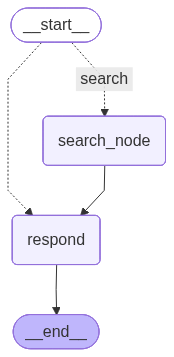

In [10]:
app

In [11]:
intial_state = ({'messages': [HumanMessage('who won the last night Cricket world cup match')]})
result = app.invoke(intial_state)

In [12]:
final_result= result['messages'][-1].content

In [13]:
result['messages']

[HumanMessage(content='who won the last night Cricket world cup match', additional_kwargs={}, response_metadata={}, id='70be79ec-4dd2-40ca-ae20-fdc55e920379'),
 HumanMessage(content='Search Results:\n[{\'title\': \'India beats Zimbabwe, South Africa beats West Indies at T20 World ...\', \'url\': \'https://www.abc.net.au/news/2026-02-27/india-south-africa-win-at-t20-world-cup/106394592\', \'content\': "Topic:Cricket\\n\\nHardik Pandya salutes the crowd as he walks off the field during the T20 World Cup.\\n\\nNo Indian batter was head and shoulders above the rest, with rapid contributions across the board. (Getty Images: Surjeet Yadav/ICC)\\n\\n## In short:\\n\\nSouth Africa has beaten the previously undefeated West Indies, and India has thumped Zimbabwe to send the Proteas into the T20 World Cup semifinals.\\n\\nSouth Africa joins England in the semis, although there are still four Super Eights games remaining.\\n\\n## What\'s next?\\n\\nThe semis will be played next Thursday and Friday

In [49]:
for i, msg in enumerate(result["messages"], 1):
    print(f"\nMessage {i}")
    print("Type:", type(msg).__name__)
    print("Content:", msg.content)
    print("-" * 40)


Message 1
Type: HumanMessage
Content: who won the last night Cricket world cup match
----------------------------------------

Message 2
Type: HumanMessage
Content: Search Results:
[{'title': 'T20 World Cup: New Zealand dump hosts Sri Lanka out ... - Sky Sports', 'url': 'https://www.skysports.com/cricket/news/12123/13512112/t20-world-cup-new-zealand-dump-hosts-sri-lanka-out-of-tournament-with-crushing-super-8s-victory', 'content': 'Sky Sports\n\nCricket\n\n#### Internationals\n\n#### Domestic\n\n#### Indian Premier League\n\n#### Domestic Leagues\n\n#### Internationals\n\n# T20 World Cup: New Zealand dump hosts Sri Lanka out of tournament with crushing Super 8s victory\n\nNew Zealand dumped out co-hosts Sri Lanka with a superb bowling display and also boosted their own semi-final hopes; watch West Indies vs South Africa at 9am and India vs Zimbabwe from 1pm on Thursday as the Super 8s continue, live on Sky Sports\n\nThursday 26 February 2026 06:46, UK\n\nNew Zealand\'s Matt Henry (AP 

In [ ]:
def build_graph():
    graph = StateGraph(AIAgent)
    graph.add_node("search_node", search_node)
    graph.add_node("respond", respond)

    # Adding Conditional Edge
    graph.set_conditional_entry_point(
        router_node, {"search": "search_node", "respond": "respond"}
    )

    graph.add_edge("search_node", "respond")

    graph.add_edge("respond", END)

    return graph.compile()


graph = build_graph()

In [16]:
from ai_agent import build_graph


In [17]:
graph = build_graph()


In [18]:
result = graph.invoke({"messages": [HumanMessage(content = "latest Cricket News")]})

In [19]:
result

{'messages': [HumanMessage(content='latest Cricket News', additional_kwargs={}, response_metadata={}, id='86b3c79f-e714-42bc-9537-edfadf6499f4'),
  HumanMessage(content='Search Results:\n[{\'title\': \'Cricket – Ashes, Test, T20 & ODI news, scores & results – BBC Sport\', \'url\': \'https://www.bbc.com/sport/cricket\', \'content\': "# Cricket\\n\\nIndia beat Zimbabwe to keep title defence alive\\n\\nDefending champions India pile on 256-4 as they eliminate Zimbabwe from the T20 World Cup with victory in Chennai.\\n\\nHardik Pandya celebrates his half-century\\n\\nEngland consider spinner Ahmed for Colombo turner\\n\\nRehan Ahmed in an England training session\\n\\nSouth Africa stay unbeaten with win over West Indies\\n\\nAiden Markram walks off with Ryan Rickelton\\n\\nWho needs what to reach T20 World Cup semi-finals?\\n\\nICC World Cup Trophy\\n\\nStumped podcast: Georgia Voll on Healy, Australia v India rivalry & coffee. AudioStumped podcast: Georgia Voll on Healy, Australia v India

In [22]:
print(result['messages'][-1].content)

Here's the latest cricket news based on the search results:

**T20 World Cup Updates:**

*   **India keeps title defence alive:** Defending champions India defeated Zimbabwe in Chennai, piling on 256-4, which eliminated Zimbabwe from the T20 World Cup.
*   **South Africa remains unbeaten:** South Africa secured another victory against West Indies, maintaining their unbeaten streak in the tournament.
*   **Sri Lanka eliminated:** Sri Lanka exited the T20 World Cup after a collapse against New Zealand.
*   **West Indies thrash Zimbabwe:** Shimron Hetmyer hammered 85 runs as West Indies comfortably beat Zimbabwe.
*   **Semi-final race:** Discussions are ongoing about the various scenarios for teams to reach the T20 World Cup semi-finals.
*   **England considering spinner:** England is contemplating including spinner Rehan Ahmed for an upcoming match on a "Colombo turner."
*   **Tournament stats:** Men's T20 World Cup tables, top run-scorers, and wicket-takers are available.

**Other Inter